In [20]:
import mlflow
import dagshub

dagshub.init(repo_owner="MitadruMridha05", repo_name="Youtube_Sentiment_Analysis", mlflow=True)


remote_server_uri = "https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow"  # Replace with your MLflow server URI
mlflow.set_tracking_uri(remote_server_uri)

with mlflow.start_run():
    mlflow.log_param("param1", 15)
    mlflow.log_metric("metric1", 0.85)

Initialized MLflow to track repo "MitadruMridha05/Youtube_Sentiment_Analysis"

Repository MitadruMridha05/Youtube_Sentiment_Analysis initialized!

🏃 View run omniscient-shark-433 at: https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow/#/experiments/1/runs/f66bf231df74488f969e6417f07737ca
🧪 View experiment at: https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow/#/experiments/1


In [ ]:
import numpy as np
import pandas as pd

In [22]:
df = pd.read_csv(r"C:\Users\mitad\OneDrive\Documents\coding_maxxing\sentiment_analysing_project\artifacts\youtube_comments_cleaned_final.csv")

In [23]:
df.drop(index=range(932225), inplace=True)

In [24]:
df.shape

(100000, 8)

In [25]:
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier

In [26]:
vectorizer = CountVectorizer(max_features=10000)

In [27]:
df['CommentText'] = df['CommentText'].fillna('')
x = vectorizer.fit_transform(df['CommentText']).toarray()
y = df['Sentiment']

In [28]:
mlflow.set_tracking_uri(remote_server_uri)

In [29]:
mlflow.set_experiment("RF_baseline_model")

<Experiment: artifact_location='mlflow-artifacts:/e1302918ba6d46a8905336d59e915d4a', creation_time=1789208769861, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789208769861, lifecycle_stage='active', name='RF_baseline_model', tags={}, trace_location=None, workspace='default'>

In [31]:
df[['CommentText', 'Sentiment']].to_csv(r"C:\Users\mitad\OneDrive\Documents\coding_maxxing\sentiment_analysing_project\artifacts\youtube_comments_cleaned_final.csv", index=False)

In [32]:
with mlflow.start_run():
    mlflow.log_artifact(r"C:\Users\mitad\OneDrive\Documents\coding_maxxing\sentiment_analysing_project\artifacts\youtube_comments_cleaned_final.csv", artifact_path="data"  )

🏃 View run gaudy-doe-924 at: https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow/#/experiments/1/runs/75a466a79ca64a6a8ef2f7a5ab40881f
🧪 View experiment at: https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow/#/experiments/1


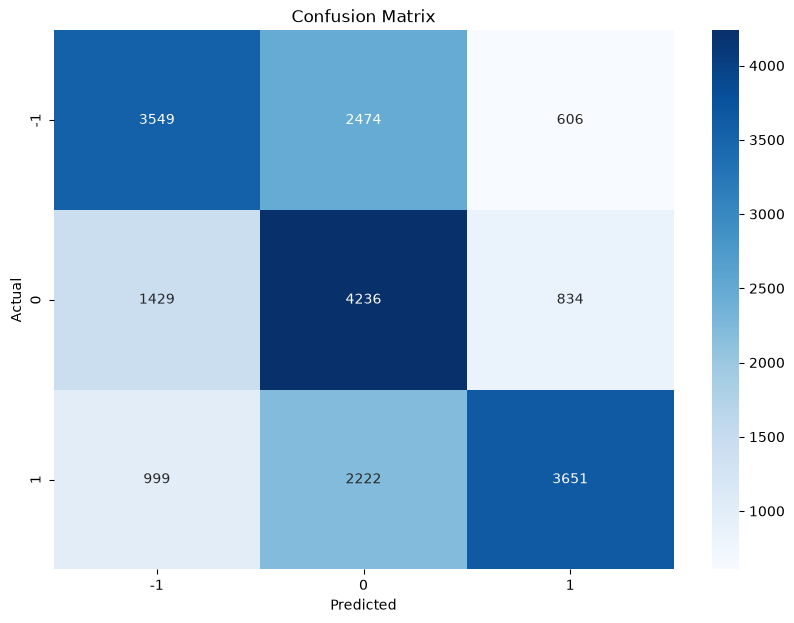

<Figure size 640x480 with 0 Axes>

2026/09/12 17:29:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/12 17:31:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run polite-bear-935 at: https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow/#/experiments/1/runs/a7931df9a3294109bcbfb5eec5256231
🧪 View experiment at: https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow/#/experiments/1
Random Forest baseline model training completed and logged to MLflow.
Accuracy: 0.5718


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

with mlflow.start_run():
    #Log a description for the run
    mlflow.set_tag("model_type", "RandomForestClassifier")
    mlflow.set_tag("experiment", "baseline_model")
    mlflow.set_tag("mlflow_runName", "RF_baseline_model")

    #Add a description 
    mlflow.set_tag("description", "This is a baseline model using Random Forest Classifier for sentiment analysis on YouTube comments.")

    #Log parameters for vectorizer and model
    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", vectorizer.max_features)

    #Log Random Forest parameters
    n_estimators = 100
    max_depth = 15

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    #initialize and train the Random Forest model
    rf_model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    rf_model.fit(x_train, y_train)

    #Make predictions
    y_pred = rf_model.predict(x_test)

    #Log metrics
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if label not in ['accuracy', 'macro avg', 'weighted avg']:
            for metric_name, metric_value in metrics.items():
                mlflow.log_metric(f"{label}_{metric_name}", metric_value)

    #Plot confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    #Save and log the confusion matrix plot
    # Define the artifact path
    artifact_path = r"C:\Users\mitad\OneDrive\Documents\coding_maxxing\sentiment_analysing_project\artifacts\confusion_matrix.png"

    # Save the confusion matrix
    plt.savefig(artifact_path, bbox_inches="tight")
    plt.show()

    # Log the saved artifact to MLflow
    mlflow.log_artifact(artifact_path, artifact_path="plots")

    # Log the trained model
    mlflow.sklearn.log_model(rf_model, "rf_baseline_model")

print("Random Forest baseline model training completed and logged to MLflow.")
print(f"Accuracy: {accuracy:.4f}")